In [1]:
import pandas as pd
import ast
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 로드 (silence 데이터는 이미 리뷰 10개 미만임)
df_silence = pd.read_csv('../../../../data/preprocessed/steam_indie_games_silence.csv')
df_graded = pd.read_csv('../../../../data/preprocessed/steam_indie_games_graded.csv')

def extract_tags(tag_str):
    try:
        if pd.isna(tag_str): return []
        return list(ast.literal_eval(tag_str).keys())
    except: return []

df_silence['tag_list'] = df_silence['tags'].apply(extract_tags)
df_graded['tag_list'] = df_graded['tags'].apply(extract_tags)

데이터를 불러오고 분석하는 중... (이번엔 확실하게 출력됩니다!)

📊 [1] 평균 가격 및 만족도(긍정률) 비교
[무명 | Silence] 평균 가격: $5.63 | 평균 긍정률: 79.7%
[생존 | Graded ] 평균 가격: $8.84 | 평균 긍정률: 84.1%

🕹️ [2] 지배 장르 점유율 (TOP 5)
            Silence (%)  Graded (%)
Indie             100.0        99.9
Adventure          42.9        49.6
Casual             53.8        42.4
Action             45.7        42.2
Simulation          0.0        25.8
Strategy           21.1         0.0

🏷️ [3] 핵심 태그 사용 비율 (TOP 10)
                Silence (%)  Graded (%)
Singleplayer           79.4        76.9
Indie                  68.7        60.5
Adventure              40.7        47.9
Casual                 52.8        43.0
Action                 45.1        41.4
2D                     46.7        41.0
3D                     36.0        33.3
Atmospheric             0.0        29.8
Exploration             0.0        28.4
Simulation              0.0        25.6
Colorful               27.2         0.0
Puzzle                 24.6         0.0
Pixel Graphics      

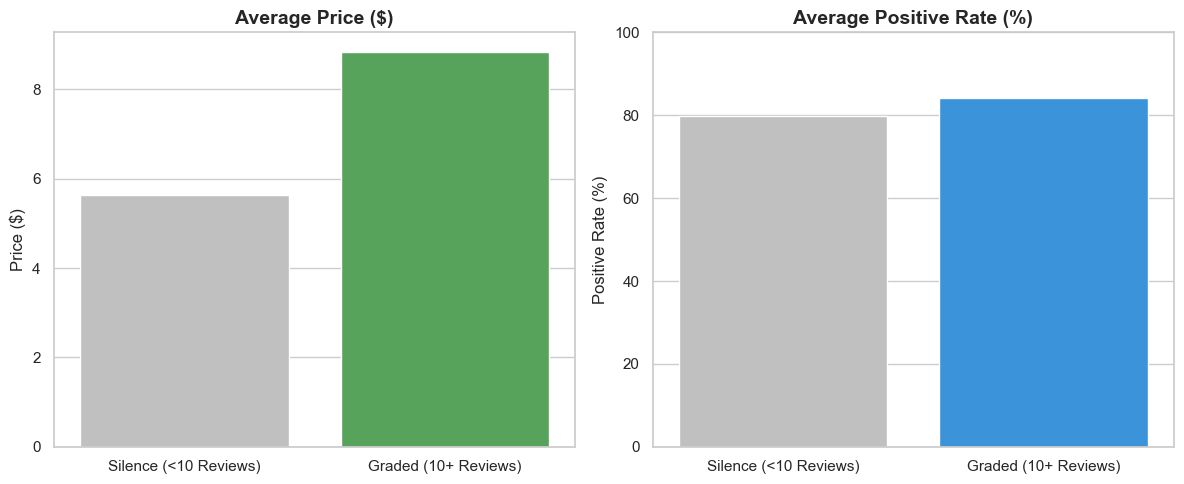

In [6]:
import pandas as pd
import ast
import json
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 시각화 기본 설정
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

print("데이터를 불러오고 분석하는 중... (이번엔 확실하게 출력됩니다!)\n")

# 2. 데이터 로드
path_silence = '../../../../data/preprocessed/steam_indie_games_silence.csv'
path_graded = '../../../../data/preprocessed/steam_indie_games_graded.csv'

df_silence = pd.read_csv(path_silence)
df_graded = pd.read_csv(path_graded)

# 3. 긍정률 계산 (분모 0 에러 방지)
for df in [df_silence, df_graded]:
    df['total_votes'] = df['positive'] + df['negative']
    df['positive_rate'] = np.where(df['total_votes'] > 0, (df['positive'] / df['total_votes']) * 100, np.nan)

# 4. 평균 가격 및 만족도 계산
silence_price = df_silence['price'].mean()
graded_price = df_graded['price'].mean()
silence_sat = df_silence['positive_rate'].dropna().mean()
graded_sat = df_graded['positive_rate'].dropna().mean()

# 🚨 [초강력 만능 파서] 딕셔너리/JSON/리스트 등 어떤 형태든 키값을 강제 추출합니다.
def universal_parser(val):
    if pd.isna(val): return []
    val_str = str(val).strip()
    if not val_str: return []
    
    # [방식 1] 일반적인 Python 딕셔너리/리스트 형태 파싱
    try:
        parsed = ast.literal_eval(val_str)
        if isinstance(parsed, dict): return list(parsed.keys())
        if isinstance(parsed, list):
            if len(parsed) > 0 and isinstance(parsed[0], dict):
                return [i.get('description', i.get('name', str(i))) for i in parsed]
            return [str(i) for i in parsed]
    except: pass
        
    # [방식 2] 쌍따옴표나 null 등이 포함된 JSON 형태 파싱
    try:
        parsed = json.loads(val_str.replace("'", '"'))
        if isinstance(parsed, dict): return list(parsed.keys())
        if isinstance(parsed, list):
            if len(parsed) > 0 and isinstance(parsed[0], dict):
                return [i.get('description', i.get('name', str(i))) for i in parsed]
            return [str(i) for i in parsed]
    except: pass

    # [방식 3] 최후의 보루: 단순 콤마로 연결된 문자열인 경우
    return [v.strip() for v in val_str.split(',') if v.strip()]

# 장르와 태그 모두에 만능 파서 적용
for df in [df_silence, df_graded]:
    df['genre_list'] = df['genres'].apply(universal_parser)
    df['tag_list'] = df['tags'].apply(universal_parser)

# 리스트 아이템 집계 함수 (빈 데이터 에러 방지 포함)
def get_top_items(series, top_n=10):
    all_items = [item for sublist in series for item in sublist]
    if not all_items: return pd.Series(dtype=float) 
    counts = pd.Series(Counter(all_items))
    return (counts / len(series) * 100).sort_values(ascending=False).head(top_n)

# =========================================================
# 결과 출력
# =========================================================
print("="*50)
print("📊 [1] 평균 가격 및 만족도(긍정률) 비교")
print("="*50)
print(f"[무명 | Silence] 평균 가격: ${silence_price:.2f} | 평균 긍정률: {silence_sat:.1f}%")
print(f"[생존 | Graded ] 평균 가격: ${graded_price:.2f} | 평균 긍정률: {graded_sat:.1f}%")

print("\n" + "="*50)
print("🕹️ [2] 지배 장르 점유율 (TOP 5)")
print("="*50)
genre_compare = pd.DataFrame({
    'Silence (%)': get_top_items(df_silence['genre_list'], 5),
    'Graded (%)': get_top_items(df_graded['genre_list'], 5)
}).fillna(0).sort_values(by='Graded (%)', ascending=False)
print(genre_compare.round(1))

print("\n" + "="*50)
print("🏷️ [3] 핵심 태그 사용 비율 (TOP 10)")
print("="*50)
tag_compare = pd.DataFrame({
    'Silence (%)': get_top_items(df_silence['tag_list'], 10),
    'Graded (%)': get_top_items(df_graded['tag_list'], 10)
}).fillna(0).sort_values(by='Graded (%)', ascending=False)
print(tag_compare.round(1))

# =========================================================
# 시각화
# =========================================================
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=['Silence (<10 Reviews)', 'Graded (10+ Reviews)'], y=[silence_price, graded_price], ax=ax[0], palette=['#C0C0C0', '#4CAF50'])
ax[0].set_title("Average Price ($)", fontsize=14, fontweight='bold')
ax[0].set_ylabel("Price ($)")

sns.barplot(x=['Silence (<10 Reviews)', 'Graded (10+ Reviews)'], y=[silence_sat, graded_sat], ax=ax[1], palette=['#C0C0C0', '#2196F3'])
ax[1].set_title("Average Positive Rate (%)", fontsize=14, fontweight='bold')
ax[1].set_ylabel("Positive Rate (%)")
ax[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

In [7]:
# 🚨 [핵심 수정 부분] Top 10을 먼저 자르지 않고, 전체 데이터의 비율을 먼저 구합니다.
def get_all_items_pct(series):
    all_items = [item for sublist in series for item in sublist]
    if not all_items: return pd.Series(dtype=float) 
    counts = pd.Series(Counter(all_items))
    return (counts / len(series)) * 100

# 장르 전체 점유율 계산 및 병합
genre_all = pd.DataFrame({
    'Silence (%)': get_all_items_pct(df_silence['genre_list']),
    'Graded (%)': get_all_items_pct(df_graded['genre_list'])
}).fillna(0)

# 태그 전체 점유율 계산 및 병합
tag_all = pd.DataFrame({
    'Silence (%)': get_all_items_pct(df_silence['tag_list']),
    'Graded (%)': get_all_items_pct(df_graded['tag_list'])
}).fillna(0)

# =========================================================
# 결과 출력 (먼저 병합한 뒤에 정렬하므로 절대 0.0으로 날아가지 않습니다)
# =========================================================
print("="*50)
print("🕹️ [2] 지배 장르 점유율 (Graded TOP 5 기준)")
print("="*50)
# 생존한 게임(Graded)들이 많이 쓰는 장르 기준으로 정렬
print(genre_all.sort_values(by='Graded (%)', ascending=False).head(5).round(1))

print("\n" + "="*50)
print("🏷️ [3] 핵심 태그 사용 비율 (Graded TOP 10 기준)")
print("="*50)
# 생존한 게임(Graded)들이 많이 쓰는 태그 기준으로 정렬
print(tag_all.sort_values(by='Graded (%)', ascending=False).head(10).round(1))

print("\n" + "="*50)
print("💀 [4] 무명(Silence)의 늪: 생존군보다 유독 많이 쓰인 '함정 태그' TOP 5")
print("="*50)
# Silence 그룹과 Graded 그룹의 점유율 격차가 가장 큰(Silence 쪽에 몰린) 태그 도출
tag_all['Gap (Sil - Grad)'] = tag_all['Silence (%)'] - tag_all['Graded (%)']
trap_tags = tag_all.sort_values(by='Gap (Sil - Grad)', ascending=False).head(5)
print(trap_tags[['Silence (%)', 'Graded (%)', 'Gap (Sil - Grad)']].round(1))

🕹️ [2] 지배 장르 점유율 (Graded TOP 5 기준)
            Silence (%)  Graded (%)
Indie             100.0        99.9
Adventure          42.9        49.6
Casual             53.8        42.4
Action             45.7        42.2
Simulation         18.5        25.8

🏷️ [3] 핵심 태그 사용 비율 (Graded TOP 10 기준)
              Silence (%)  Graded (%)
Singleplayer         79.4        76.9
Indie                68.7        60.5
Adventure            40.7        47.9
Casual               52.8        43.0
Action               45.1        41.4
2D                   46.7        41.0
3D                   36.0        33.3
Atmospheric          21.9        29.8
Exploration          21.2        28.4
Simulation           17.8        25.6

💀 [4] 무명(Silence)의 늪: 생존군보다 유독 많이 쓰인 '함정 태그' TOP 5
        Silence (%)  Graded (%)  Gap (Sil - Grad)
Casual         52.8        43.0               9.7
Indie          68.7        60.5               8.3
Arcade         21.7        14.0               7.8
2D             46.7        41.0         